# Machine Learning Basics: Theory
**Module**: Machine Learning Foundations  


## What You Will Learn

- Explain why machine learning is required in modern applications
- Understand supervised and unsupervised learning in plain language
- Learn classification first (with very easy examples)
- Differentiate classification, regression, and clustering
- Run 10 beginner-friendly question-code examples in sequence
- Use a final linear-regression demo only at the end (with visual support plots)

## Segment 1: Why Machine Learning Is Required
Traditional programming works well when rules are fixed and easy to write.
Real-world data problems are often noisy and changing, so manual rules break quickly.
Machine learning helps by learning patterns from historical data and generalizing to new cases.
In practice, ML is used when prediction quality matters and writing all rules manually is not realistic.

## Segment 2: What Is Machine Learning?
Machine learning is a method where computers learn patterns from examples instead of explicit rule lists.
You provide input data (features) and expected outputs (labels/targets) for training.
The model learns a mapping and then predicts outputs for unseen data.
The quality of prediction depends on data quality, model choice, and evaluation strategy.

## Classification vs Regression vs Other ML Tasks
| Task Type | Output Type | Beginner Example |
|---|---|---|
| Classification | Category/label | Will a student pass or fail? |
| Regression | Continuous number | What will next month's sales be? |
| Clustering | Group assignment (no labels given) | Which customer segment is similar? |
| Recommendation | Ranked items | Which movie should this user watch next? |
| Anomaly Detection | Normal vs unusual behavior | Is this transaction suspicious? |

we first focus on **classification** because it is easier to understand early.
We move to **linear regression only in the last code example**...

## Core Terminology You Must Know
- **Feature (X)**: Input information used for prediction
- **Target/Label (y)**: Output we want to predict
- **Model**: Mathematical function learned from data
- **Training set**: Data used to learn model parameters
- **Test set**: Data kept aside for honest evaluation
- **Overfitting**: Model memorizes training data and fails on new data
- **Underfitting**: Model is too simple to capture real patterns

## Standard Beginner Workflow
1. Understand the problem and define input/output
2. Collect and inspect data
3. Split into train and test sets
4. Train a simple baseline model
5. Evaluate with correct metrics
6. Improve carefully and re-evaluate

This means solving ML step by step from problem clarity to honest evaluation, instead of jumping directly to complex models.

### Q1. What does a beginner classification dataset look like?
Goal: create a small student table where the target is pass/fail (0 or 1).

In [ ]:
import pandas as pd

student_df = pd.DataFrame({
    "hours_studied": [1, 2, 3, 4, 5, 6, 7, 8],
    "attendance_pct": [50, 55, 60, 65, 70, 75, 80, 85],
    "passed": [0, 0, 0, 0, 1, 1, 1, 1]
})

print(student_df.head())
print("Rows:", len(student_df))

   hours_studied  attendance_pct  passed
0              1              50       0
1              2              55       0
2              3              60       0
3              4              65       0
4              5              70       1
Rows: 8


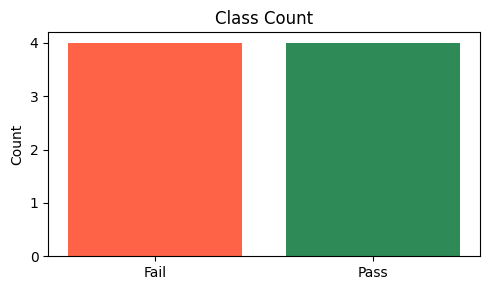

In [22]:
#The visualization code after each demo code is only for your practice and can be skipped while revising.
import matplotlib.pyplot as plt

counts = student_df["passed"].value_counts().sort_index()

plt.figure(figsize=(5, 3))
plt.bar(["Fail", "Pass"], counts.values, color=["tomato", "seagreen"] )
plt.title("Class Count")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

We created a beginner classification dataset with two input features and one binary target.
The key parameters were `hours_studied`, `attendance_pct`, and `passed` where 0 means fail and 1 means pass.
This gives a clean supervised-learning table that we can use in the next steps.

### Q2. What is the target in classification, and how are classes distributed?
Goal: inspect class counts so students can see what 0 and 1 mean.

In [ ]:
print("0 = Fail, 1 = Pass")
print(student_df["passed"].value_counts().sort_index())
print(student_df[["hours_studied", "attendance_pct"]].head())

0 = Fail, 1 = Pass
passed
0    4
1    4
Name: count, dtype: int64
   hours_studied  attendance_pct
0              1              50
1              2              55
2              3              60
3              4              65
4              5              70


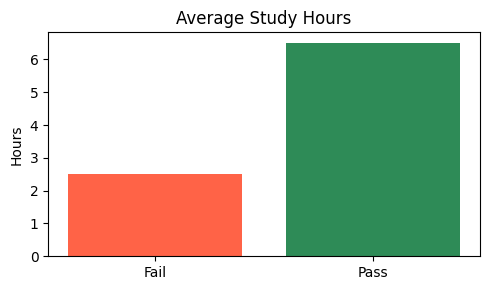

In [ ]:
import matplotlib.pyplot as plt

avg_hours = student_df.groupby("passed")["hours_studied"].mean()

plt.figure(figsize=(5, 3))
plt.bar(["Fail", "Pass"], avg_hours.values, color=["tomato", "seagreen"] )
plt.title("Average Study Hours")
plt.ylabel("Hours")
plt.tight_layout()
plt.show()

We checked the class labels and printed a quick snapshot of the input columns.
The key parameters used were `value_counts()` for class totals and `head()` for a quick data preview.
The graph above compares average study hours for fail and pass groups.

### Q3. How do we separate features (X) and target (y) for classification?
Goal: prepare input columns and output label in scikit-learn format.

In [ ]:
X_cls = student_df[["hours_studied", "attendance_pct"]]
y_cls = student_df["passed"]

print("X (features):")
print(X_cls.head())
print("\ny (target):")
print(y_cls.head())
print("\nShape of X:", X_cls.shape, "| Shape of y:", y_cls.shape)

X (features):
   hours_studied  attendance_pct
0              1              50
1              2              55
2              3              60
3              4              65
4              5              70

y (target):
0    0
1    0
2    0
3    0
4    1
Name: passed, dtype: int64

Shape of X: (8, 2) | Shape of y: (8,)


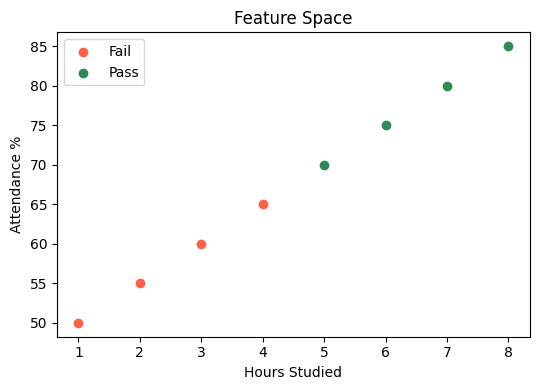

In [ ]:
import matplotlib.pyplot as plt

fail_df = student_df[student_df["passed"] == 0]
pass_df = student_df[student_df["passed"] == 1]

plt.figure(figsize=(5.5, 4))
plt.scatter(fail_df["hours_studied"], fail_df["attendance_pct"], color="tomato", label="Fail")
plt.scatter(pass_df["hours_studied"], pass_df["attendance_pct"], color="seagreen", label="Pass")
plt.title("Feature Space")
plt.xlabel("Hours Studied")
plt.ylabel("Attendance %")
plt.legend()
plt.tight_layout()
plt.show()

We separated model inputs into `X_cls` and the output label into `y_cls`.
The parameters used were two features (`hours_studied`, `attendance_pct`) and one target (`passed`).
The graph above shows how fail/pass groups occupy different regions in feature space.

### Q4. Why do we split into train and test sets?
Goal: keep some unseen data for honest model checking.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_cls, y_cls, test_size=0.25, random_state=42
)

print("Train rows:", len(X_train))
print("Test rows:", len(X_test))

Train rows: 6
Test rows: 2


We split data into train and test groups so evaluation uses unseen examples.
The key parameters were `test_size=0.25` and `random_state=42` for repeatable splitting.
The graph above shows only the train and test row counts, which is easy to read for beginners.

### Q5. How do we train a simple classification model?
Goal: use Logistic Regression for pass/fail prediction (binary classification).

In [23]:
from sklearn.linear_model import LogisticRegression

cls_model = LogisticRegression()
cls_model.fit(X_train, y_train)

print("Intercept:", round(cls_model.intercept_[0], 2))
print("Coefficient (hours_studied):", round(cls_model.coef_[0][0], 2))
print("Coefficient (attendance_pct):", round(cls_model.coef_[0][1], 2))

Intercept: -48.63
Coefficient (hours_studied): 0.14
Coefficient (attendance_pct): 0.71


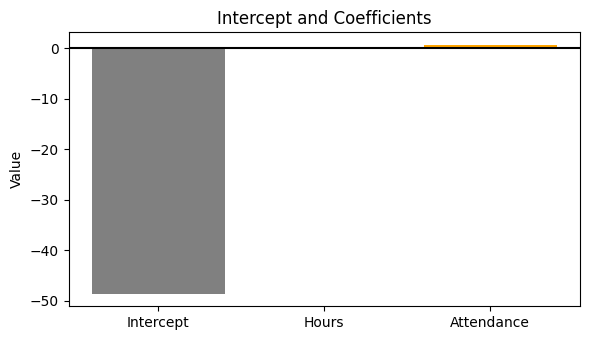

In [ ]:
import matplotlib.pyplot as plt

labels = ["Intercept", "Hours", "Attendance"]
values = [cls_model.intercept_[0], cls_model.coef_[0][0], cls_model.coef_[0][1]]

plt.figure(figsize=(6, 3.5))
plt.bar(labels, values, color=["gray", "skyblue", "orange"] )
plt.axhline(0, color="black")
plt.title("Intercept and Coefficients")
plt.ylabel("Value")
plt.tight_layout()
plt.show()

We trained a Logistic Regression model on the training split for binary classification.
The key parameters were default Logistic Regression settings with two inputs and one binary output.
The graph above visualizes intercept and coefficients so students can compare direction and strength of each feature.

### Q6. How do we evaluate a classification model?
Goal: check accuracy, confusion matrix, and precision/recall summary.

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix

y_pred = cls_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 2))
print("Confusion matrix:")
print(cm)

Accuracy: 1.0
Confusion matrix:
[[1 0]
 [0 1]]


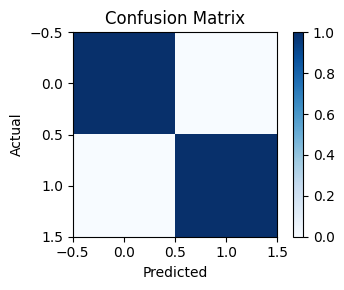

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4, 3))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.tight_layout()
plt.show()

We evaluated the classifier using two simple outputs: accuracy and confusion matrix.
The parameters used were predicted labels from `cls_model.predict(X_test)` and actual labels `y_test`.
The graph above visualizes the same confusion matrix in a color map.

### Q7. How do we predict for new students and show pass probability?
Goal: make predictions for unseen inputs and show confidence from the classifier.

In [24]:
new_students = pd.DataFrame({
    "hours_studied": [3, 6, 9],
    "attendance_pct": [58, 72, 86]
})

pred_probs = cls_model.predict_proba(new_students)[:, 1]

result_df = new_students.copy()
result_df["pass_probability"] = pred_probs.round(2)
result_df["predicted_pass"] = (pred_probs >= 0.5).astype(int)

print(result_df)

   hours_studied  attendance_pct  pass_probability  predicted_pass
0              3              58              0.00               0
1              6              72              0.97               1
2              9              86              1.00               1


We predicted pass/fail labels for new student records and also printed pass probability.
The key parameters were new input values for study hours and attendance plus `predict_proba` for confidence.
This helps students understand both class output and model certainty.

In [ ]:
new_students = pd.DataFrame({
    "hours_studied": [3, 6, 9],
    "attendance_pct": [58, 72, 86]
})

pred_probs = cls_model.predict_proba(new_students)[:, 1]

result_df = new_students.copy()
result_df["pass_probability"] = pred_probs.round(2)
result_df["predicted_pass"] = (pred_probs >= 0.5).astype(int)

print(result_df)

   hours_studied  attendance_pct  pass_probability  predicted_pass
0              3              58              0.00               0
1              6              72              0.97               1
2              9              86              1.00               1


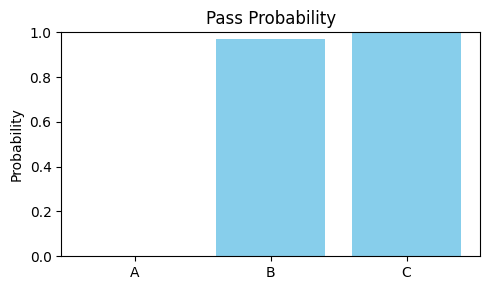

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 3))
plt.bar(["A", "B", "C"], result_df["pass_probability"], color="skyblue")
plt.ylim(0, 1)
plt.title("Pass Probability")
plt.ylabel("Probability")
plt.tight_layout()
plt.show()

We predicted pass/fail labels for new student records and also printed pass probability.
The key parameters were new input values for study hours and attendance plus `predict_proba` for confidence.
This helps students understand both class output and model certainty.

### Q8. What does multi-class classification look like?
Goal: use Logistic Regression on a 3-class dataset (Iris).
The Iris dataset contains flower measurements: sepal length, sepal width, petal length, and petal width.
Its target column has 3 classes representing species labels, which makes it ideal for a first multi-class example.

In [ ]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
iris_df = iris.frame

print("Iris data preview:")
print(iris_df.head())
print("Shape:", iris_df.shape)
print("Classes:", list(iris.target_names))

X_iris = iris_df[["sepal length (cm)", "petal length (cm)"]]
y_iris = iris_df["target"]

Xi_train, Xi_test, yi_train, yi_test = train_test_split(
    X_iris, y_iris, test_size=0.25, random_state=42
)

multi_cls_model = LogisticRegression(max_iter=200)
multi_cls_model.fit(Xi_train, yi_train)
yi_pred = multi_cls_model.predict(Xi_test)

print("Accuracy:", round(accuracy_score(yi_test, yi_pred), 2))

Iris data preview:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  
Shape: (150, 5)
Classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
Accuracy: 1.0


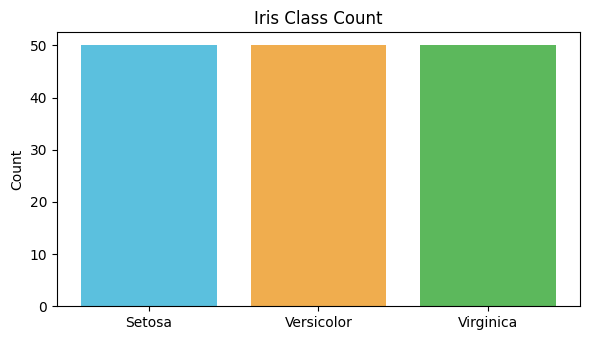

In [ ]:
import matplotlib.pyplot as plt

class_counts = iris_df["target"].value_counts().sort_index()

plt.figure(figsize=(6, 3.5))
plt.bar(["Setosa", "Versicolor", "Virginica"], class_counts.values, color=["#5bc0de", "#f0ad4e", "#5cb85c"] )
plt.title("Iris Class Count")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

We trained a multi-class Logistic Regression model and predicted Iris class labels.
The key parameters were two easy features, a 25% test split, and `max_iter=200`.
This keeps multi-class training simple while still showing a real dataset.

### Q9. How does threshold change affect classification output?
Goal: compare default threshold (0.5) with a stricter threshold (0.6).

In [ ]:
from sklearn.metrics import accuracy_score

prob = cls_model.predict_proba(X_test)[:, 1]
pred_05 = (prob >= 0.5).astype(int)
pred_06 = (prob >= 0.6).astype(int)

acc_05 = accuracy_score(y_test, pred_05)
acc_06 = accuracy_score(y_test, pred_06)

print("Accuracy at threshold 0.5:", round(acc_05, 2))
print("Accuracy at threshold 0.6:", round(acc_06, 2))

Accuracy at threshold 0.5: 1.0
Accuracy at threshold 0.6: 1.0


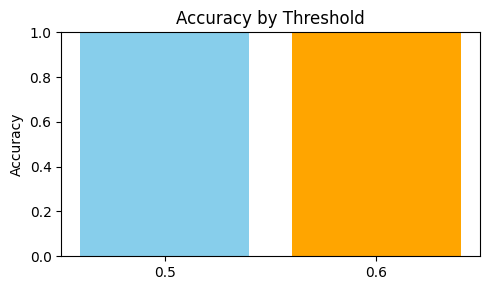

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 3))
plt.bar(["0.5", "0.6"], [acc_05, acc_06], color=["skyblue", "orange"] )
plt.ylim(0, 1)
plt.title("Accuracy by Threshold")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.show()

We compared default and custom probability thresholds for the same classifier.
The key parameter was `threshold=0.6`, which changes predicted labels compared to the default 0.5 rule.
This helps students see how business rules can shift model decisions without retraining.

### Q10. Final linear regression example: predict one missing sales value
Goal: train regression once at the end and fill one missing target value.

In [27]:
import numpy as np
from sklearn.linear_model import LinearRegression

reg_df = pd.DataFrame({
    "ad_spend": [10, 20, 30, 40, 50, 60],
    "sales": [10, 27, np.nan, 45, 65, 85]
})

known_df = reg_df.dropna()
X_reg = known_df[["ad_spend"]]
y_reg = known_df["sales"]

lin_model = LinearRegression()
lin_model.fit(X_reg, y_reg)

missing_spend = reg_df.loc[reg_df["sales"].isna(), "ad_spend"].iloc[0]
pred_missing_sales = lin_model.predict(pd.DataFrame({"ad_spend": [missing_spend]}))[0]
reg_df.loc[reg_df["sales"].isna(), "sales"] = round(pred_missing_sales, 2)

print("Intercept:", round(lin_model.intercept_, 2))
print("Coefficient:", round(lin_model.coef_[0], 2))
print("Predicted missing sales:", round(pred_missing_sales, 2))
print(reg_df)

Intercept: -4.63
Coefficient: 1.42
Predicted missing sales: 37.9
   ad_spend  sales
0        10   10.0
1        20   27.0
2        30   37.9
3        40   45.0
4        50   65.0
5        60   85.0


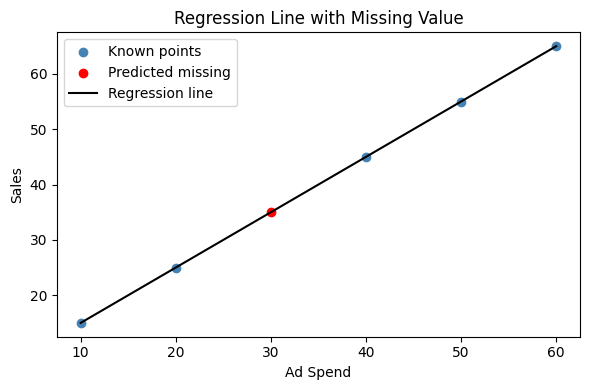

In [ ]:
import matplotlib.pyplot as plt

line_x = np.array([reg_df["ad_spend"].min(), reg_df["ad_spend"].max()])
line_y = lin_model.predict(pd.DataFrame({"ad_spend": line_x}))

plt.figure(figsize=(6, 4))
plt.scatter(known_df["ad_spend"], known_df["sales"], color="steelblue", label="Known points")
plt.scatter([missing_spend], [pred_missing_sales], color="red", label="Predicted missing")
plt.plot(line_x, line_y, color="black", label="Regression line")
plt.title("Regression Line with Missing Value")
plt.xlabel("Ad Spend")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.show()

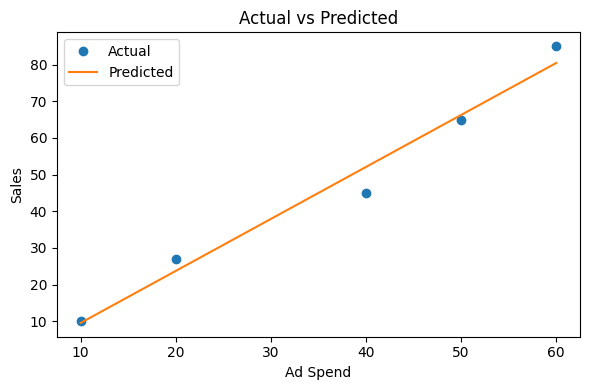

In [28]:
import matplotlib.pyplot as plt

pred_train = lin_model.predict(X_reg)

plt.figure(figsize=(6, 4))
plt.plot(known_df["ad_spend"], known_df["sales"], "o", label="Actual")
plt.plot(known_df["ad_spend"], pred_train, "-", label="Predicted")
plt.title("Actual vs Predicted")
plt.xlabel("Ad Spend")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.show()

We trained Linear Regression only at the end and predicted the single missing sales value.
The main parameters were one feature (`ad_spend`) and one target (`sales`) with automatic best-fit line learning.
Graph 1 shows known points, the predicted missing point, and the fitted line on the same axis.

Graph 2 compares actual values with model-predicted values on known points.
The key parameters were the same `ad_spend` feature and predicted outputs from the trained linear model.
This gives a quick visual check of how closely predictions follow the data pattern.